# Phase 3 Project: Predicting H1N1 Vaccination Status

# ==============================
## 1. Business Understanding
# ==============================


#### *Objective:*
The primary goal is to *predict whether an individual received the H1N1 flu vaccine* based on their backgrounds, opinions, and health behaviors.

#### *Why It Matters:*
1. *Public Health Strategy:* Understanding factors that lead to vaccination helps officials design better outreach programs.
2. *Pandemic Preparedness:* Insights from the 2009 H1N1 pandemic can inform responses to future respiratory disease outbreaks.
3. *Resource Allocation:* Identifying demographic groups with low vaccination rates allows for targeted resource distribution.

#### *Key Stakeholders:*
1. *Public Health Officials (e.g., CDC):* For policy-making and communication strategies.
2. *Healthcare Providers:* To understand patient barriers to vaccination.
3. *Pharmaceutical Companies:* For vaccine distribution planning.

#### *Problem Description:*
Using the National 2009 H1N1 Flu Survey data, we aim to answer:
1. What behavioral factors (e.g., hand washing, mask wearing) correlate with vaccination?
2. How do opinions on vaccine effectiveness and risk influence the decision to get vaccinated?
3. Which demographic features are the strongest predictors of H1N1 vaccination status?

#### *Expected Outcome:*
A classification model that predicts vaccination status and identifies key drivers, providing actionable insights for public health campaigns.

# ==============================
## 2. Setup
# ==============================

In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, plot_roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# ==============================
## 3. Data Understanding
# ==============================

In [246]:
# Load datasets
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')

# Merge features and labels
df = features.merge(labels, on='respondent_id')

print(df.shape)
df.head()

(26707, 38)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

In [248]:
# Investigate the classes
print(df['h1n1_vaccine'].value_counts(normalize=True))

0    0.787546
1    0.212454
Name: h1n1_vaccine, dtype: float64


### Exploratory Data Analysis (EDA)
Exploring relationships between key features and the target variable.

In [249]:
def plot_vaccination_rate(df, col):
    rate = df.groupby(col)['h1n1_vaccine'].mean() * 100
    rate.plot(kind='bar')
    plt.title(f'Vaccination Rate by {col}')
    plt.ylabel('% Vaccinated')
    plt.show()

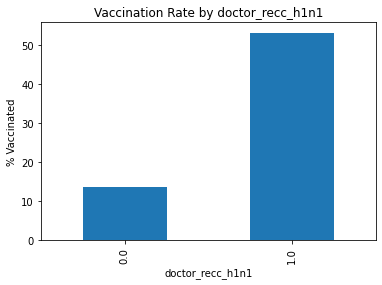

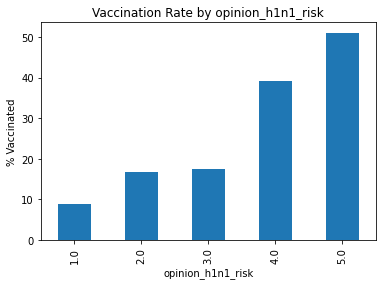

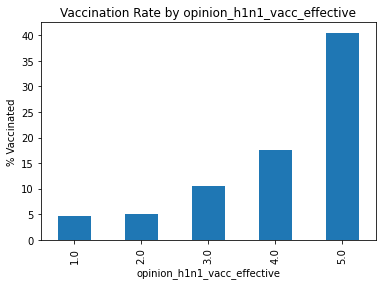

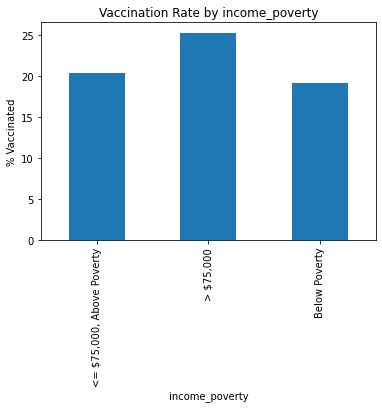

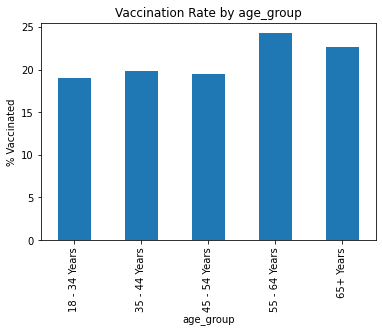

In [250]:
plot_vaccination_rate(df, 'doctor_recc_h1n1')
plot_vaccination_rate(df, 'opinion_h1n1_risk')
plot_vaccination_rate(df, 'opinion_h1n1_vacc_effective')
plot_vaccination_rate(df, 'income_poverty')
plot_vaccination_rate(df, 'age_group')

In [251]:
behavioral_cols = ['behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_avoidance']

for col in behavioral_cols:
    rate = df.groupby(col)['h1n1_vaccine'].mean() * 100
    print(f"Vaccination rate for {col}:")
    print(rate)
    print("-" * 30)

Vaccination rate for behavioral_face_mask:
behavioral_face_mask
0.0    20.453173
1.0    31.830527
Name: h1n1_vaccine, dtype: float64
------------------------------
Vaccination rate for behavioral_wash_hands:
behavioral_wash_hands
0.0    14.602151
1.0    22.657279
Name: h1n1_vaccine, dtype: float64
------------------------------
Vaccination rate for behavioral_avoidance:
behavioral_avoidance
0.0    18.113052
1.0    22.488038
Name: h1n1_vaccine, dtype: float64
------------------------------


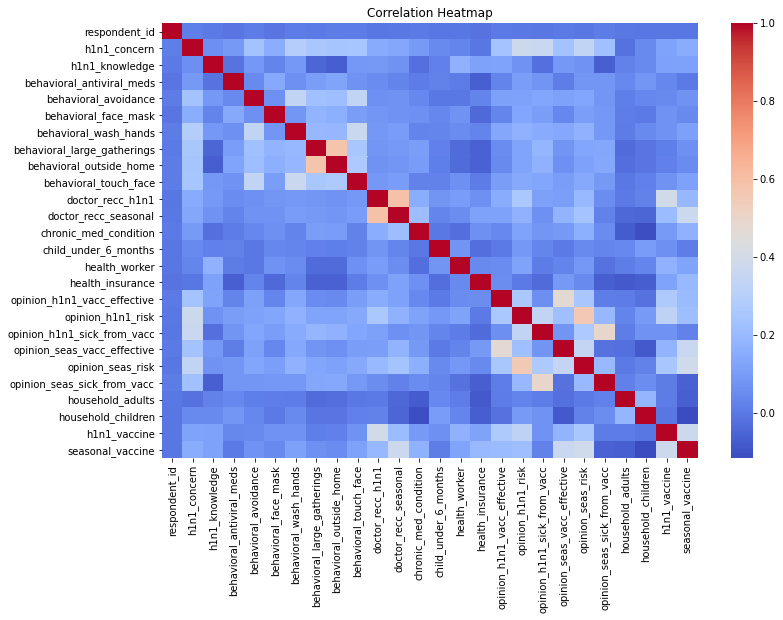

In [252]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(num_cols.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

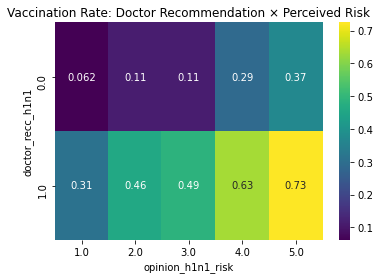

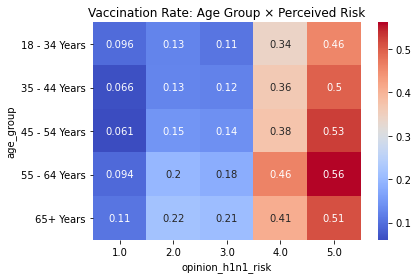

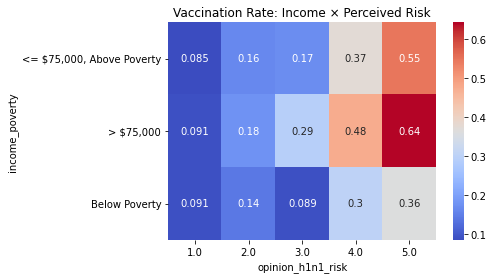

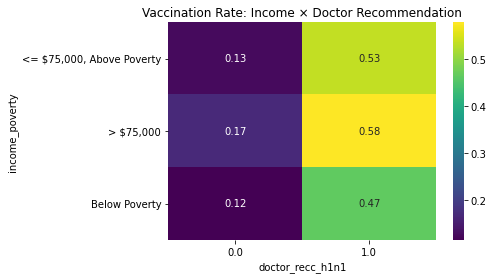

In [253]:
# Interaction between Doctor Recommendation & Perceived Risk
doc_cern = pd.crosstab(
    df['doctor_recc_h1n1'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(doc_cern, annot=True, cmap='viridis')
plt.title("Vaccination Rate: Doctor Recommendation × Perceived Risk")
plt.show()


# Interaction between Age Group & Perceived Risk of H1N1
age_risk = pd.crosstab(
    df['age_group'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(age_risk, annot=True, cmap='coolwarm')
plt.title("Vaccination Rate: Age Group × Perceived Risk")
plt.show()


# Interaction between Income & Perceived Risk of H1N1
income_risk = pd.crosstab(
    df['income_poverty'],
    df['opinion_h1n1_risk'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(income_risk, annot=True, cmap='coolwarm')
plt.title("Vaccination Rate: Income × Perceived Risk")
plt.show()


# Interaction between Income & Doctor Recommendation
income_doc = pd.crosstab(
    df['income_poverty'],
    df['doctor_recc_h1n1'],
    values=df['h1n1_vaccine'],
    aggfunc='mean'
)

sns.heatmap(income_doc, annot=True, cmap='viridis')
plt.title("Vaccination Rate: Income × Doctor Recommendation")
plt.show()

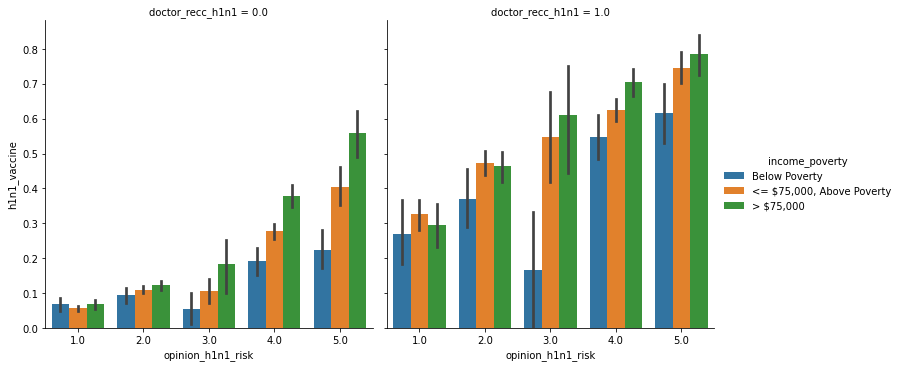

In [254]:
sns.catplot(
    data=df,
    x='opinion_h1n1_risk',
    y='h1n1_vaccine',
    hue='income_poverty',
    col='doctor_recc_h1n1',
    kind='bar'
)

# ==============================
## 4. Data Cleaning
# ==============================

In [255]:
def clean_data(df):
    df = df.copy()

    missing = df.isna().sum()
    threshold = 0.5 * len(df)
    cols_to_drop = missing[missing > threshold].index.tolist()

    cols_to_drop += ['respondent_id', 'seasonal_vaccine']

    df = df.drop(columns=cols_to_drop)

    return df

df_clean = clean_data(df)

In [256]:
# Check for duplicates
print(f"Number of duplicate rows: {df_clean.duplicated().sum()}")

Number of duplicate rows: 0


# ==============================
## 5. Preprocessing
# ==============================

In [257]:
X = df_clean.drop(columns='h1n1_vaccine')
y = df_clean['h1n1_vaccine']

In [258]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [259]:
def build_preprocessor(X):
    cat_cols = X.select_dtypes(include='object').columns
    num_cols = X.select_dtypes(include='number').columns

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer([
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ])

    return preprocessor, cat_cols, num_cols

In [260]:
preprocessor, cat_cols, num_cols = build_preprocessor(X)

# ==============================
## 6. Modeling
# ==============================

### 6.1 Logistic Regression (base)

In [261]:
# Define the SMOTE Logistic Regression Pipeline
logreg_smote_model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# Fit the model
logreg_smote_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_log = logreg_smote_model.predict(X_test)
# [:, 1] takes the probability of the positive class (Vaccinated)
y_prob_log = logreg_smote_model.predict_proba(X_test)[:, 1]

In [262]:
result_log = permutation_importance(
    logreg_smote_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Put into dataframe
perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_log.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance.head(10)

,feature,importance
9,doctor_recc_h1n1,0.082853
16,opinion_h1n1_risk,0.021883
15,opinion_h1n1_vacc_effective,0.016960
10,doctor_recc_seasonal,0.004568
13,health_worker,0.004343
33,employment_industry,0.003388
29,hhs_geo_region,0.001853
6,behavioral_large_gatherings,0.001254
28,employment_status,0.000955
8,behavioral_touch_face,0.000730


### 6.2 Logistic Regression (Tuned)

In [263]:
param_grid_log = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

# Ensure the search uses the SMOTE pipeline
grid_log = GridSearchCV(
    logreg_smote_model,
    param_grid_log,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

best_log_model = grid_log.best_estimator_

In [264]:
y_prob_tuned_log = best_log_model.predict_proba(X_test)[:,1]
y_pred_tuned_log = best_log_model.predict(X_test)

In [265]:
result_tuned_log = permutation_importance(
    best_log_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Put into dataframe
perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_tuned_log.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance.head(10)

,feature,importance
9,doctor_recc_h1n1,0.083714
16,opinion_h1n1_risk,0.022201
15,opinion_h1n1_vacc_effective,0.015593
13,health_worker,0.004624
10,doctor_recc_seasonal,0.003220
33,employment_industry,0.002677
29,hhs_geo_region,0.001891
8,behavioral_touch_face,0.001647
26,marital_status,0.001254
6,behavioral_large_gatherings,0.000973


### 6.3 Decision Tree (base)

In [266]:
dt_smote_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Fit the model
dt_smote_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_dt = dt_smote_model.predict(X_test)
y_prob_dt = dt_smote_model.predict_proba(X_test)[:, 1]

In [267]:
result_dt = permutation_importance(
    dt_smote_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_dt = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_dt.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance_dt.head(10)

,feature,importance
9,doctor_recc_h1n1,0.042493
16,opinion_h1n1_risk,0.026750
15,opinion_h1n1_vacc_effective,0.019506
19,opinion_seas_risk,0.007918
28,employment_status,0.005915
21,age_group,0.005110
31,household_adults,0.004362
17,opinion_h1n1_sick_from_vacc,0.003950
10,doctor_recc_seasonal,0.003482
22,education,0.003463


### 6.4 Decision Tree (Tuned)

In [268]:
param_grid = {
    'classifier__max_depth': [3, 5, 10],
    'classifier__min_samples_leaf': [1, 5, 10]}


grid_search = GridSearchCV(dt_smote_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_smote_dt = grid_search.best_estimator_

# print(f"Best Parameters: {grid_search.best_params_}")

In [269]:
y_prob_tuned_tree = best_smote_dt.predict_proba(X_test)[:, 1]
y_pred_tuned_tree = best_smote_dt.predict(X_test)

In [270]:
result_tuned_tree = permutation_importance(
    best_smote_dt,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_tuned = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result_tuned_tree.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance_tuned.head(10)

,feature,importance
9,doctor_recc_h1n1,0.086335
16,opinion_h1n1_risk,0.020255
15,opinion_h1n1_vacc_effective,0.016904
23,race,0.006346
18,opinion_seas_vacc_effective,0.002752
20,opinion_seas_sick_from_vacc,0.000000
21,age_group,0.000000
22,education,0.000000
24,sex,0.000000
0,h1n1_concern,0.000000


# ==============================
## 7. Evaluation
# ==============================

### 7.1 Logistic Regression (base)

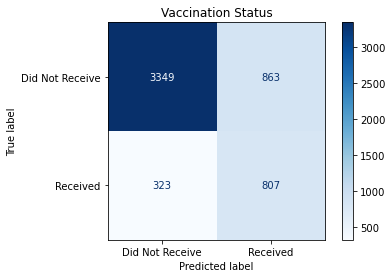

------------------------------
ROC-AUC Score: 0.8286
------------------------------
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.71      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



In [271]:
cnf_matrix = confusion_matrix(y_test, y_pred_log)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Vaccination Status')
plt.show()

print("-" * 30)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_log))

### 7.2 Logistic Regression (Tuned)

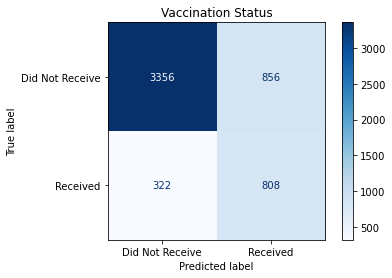

------------------------------
ROC-AUC Score: 0.8292
------------------------------
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.49      0.72      0.58      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.76      0.71      5342
weighted avg       0.82      0.78      0.79      5342



In [272]:
cnf_matrix = confusion_matrix(y_test, y_pred_tuned_log)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Vaccination Status')
plt.show()

print("-" * 30)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_tuned_log):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_tuned_log))

### 7.3 Decision Tree (base)

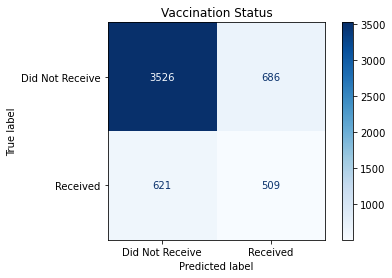

------------------------------
ROC-AUC: 0.6438
------------------------------
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      4212
           1       0.43      0.45      0.44      1130

    accuracy                           0.76      5342
   macro avg       0.64      0.64      0.64      5342
weighted avg       0.76      0.76      0.76      5342



In [273]:
cnf_matrix = confusion_matrix(y_test, y_pred_dt)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Vaccination Status')
plt.show()

print("-" * 30)
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_dt))

### 7.4 Decision Tree (Tuned)

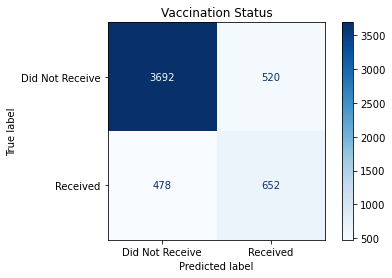

------------------------------
ROC-AUC: 0.8063
------------------------------
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4212
           1       0.56      0.58      0.57      1130

    accuracy                           0.81      5342
   macro avg       0.72      0.73      0.72      5342
weighted avg       0.82      0.81      0.81      5342



In [274]:
cnf_matrix = confusion_matrix(y_test, y_pred_tuned_tree)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=["Did Not Receive", "Received"])

disp.plot(cmap="Blues")
plt.title('Vaccination Status')
plt.show()

print("-" * 30)
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned_tree):.4f}")
print("-" * 30)
print(classification_report(y_test, y_pred_tuned_tree))

### 7.5 ROC Curves

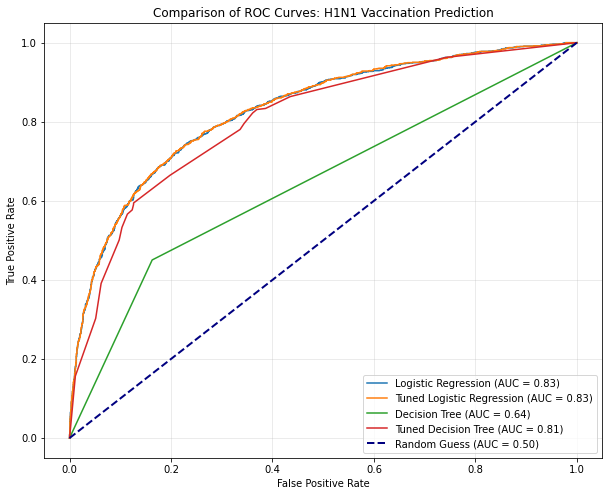

In [275]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC for base Logistic Regression
plot_roc_curve(logreg_smote_model, X_test, y_test, ax=ax, name='Logistic Regression')

# Plot ROC for Tuned Logistic Regression
plot_roc_curve(best_log_model, X_test, y_test, ax=ax, name='Tuned Logistic Regression')

# Plot ROC for base Decision Tree
plot_roc_curve(dt_smote_model, X_test, y_test, ax=ax, name='Decision Tree')

# Plot ROC for Tuned Decision Tree
plot_roc_curve(best_smote_dt, X_test, y_test, ax=ax, name='Tuned Decision Tree')

# Add a "Random Guess" diagonal line for reference
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.title('Comparison of ROC Curves: H1N1 Vaccination Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ==============================
## 8. Conclusions & Recommendations
# ==============================